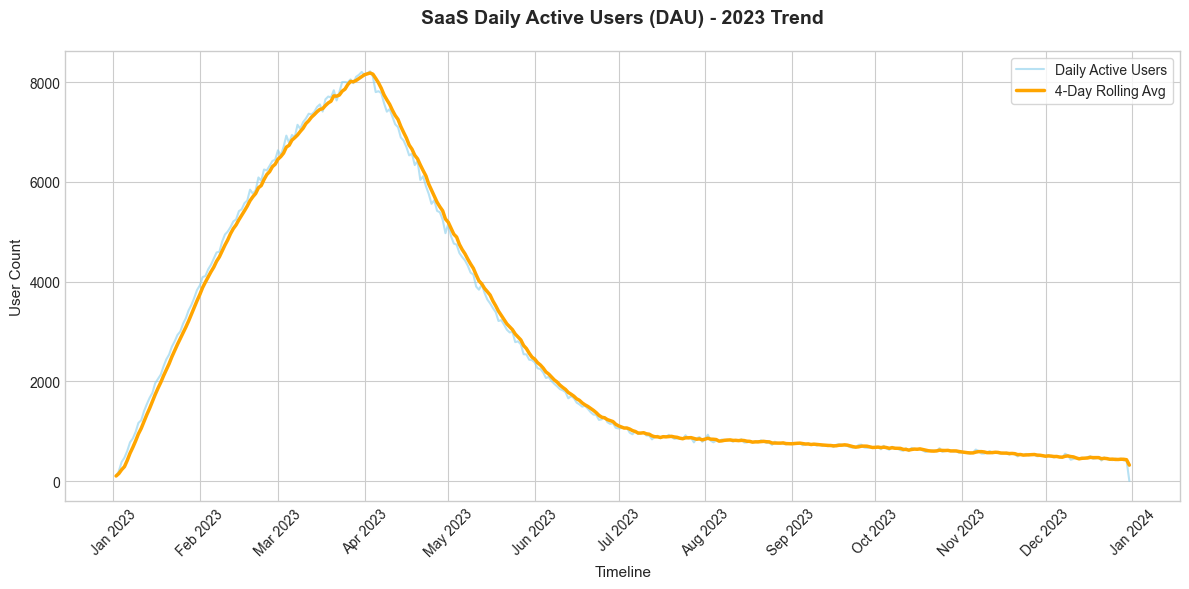

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Load data
df = pd.read_csv("data/csv_files/dau.csv")

# 2. Convert to datetime (Crucial for fixing the X-axis)
df['activity_date'] = pd.to_datetime(df['activity_date'])

# 3. Setup Plot
plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-whitegrid') # Cleaner look

# 4. Plot DAU and Rolling Average
plt.plot(df['activity_date'], df['dau'], label="Daily Active Users", color='skyblue', alpha=0.6)
plt.plot(df['activity_date'], df['rolling_4_day_avg'], label="4-Day Rolling Avg", color='orange', linewidth=2.5)

# 5. Fix the "Black Smear" (The Ticker Logic)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator()) # One label per month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) # Format: Jan 2023

# 6. Labeling
plt.title("SaaS Daily Active Users (DAU) - 2023 Trend", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Timeline", fontsize=11)
plt.ylabel("User Count", fontsize=11)
plt.xticks(rotation=45)
plt.legend(frameon=True, loc='upper right')

# 7. Final Polish and Save
plt.tight_layout()
plt.savefig("visuals/01_dau_trend.png", dpi=300) # High-res for GitHub
plt.show()

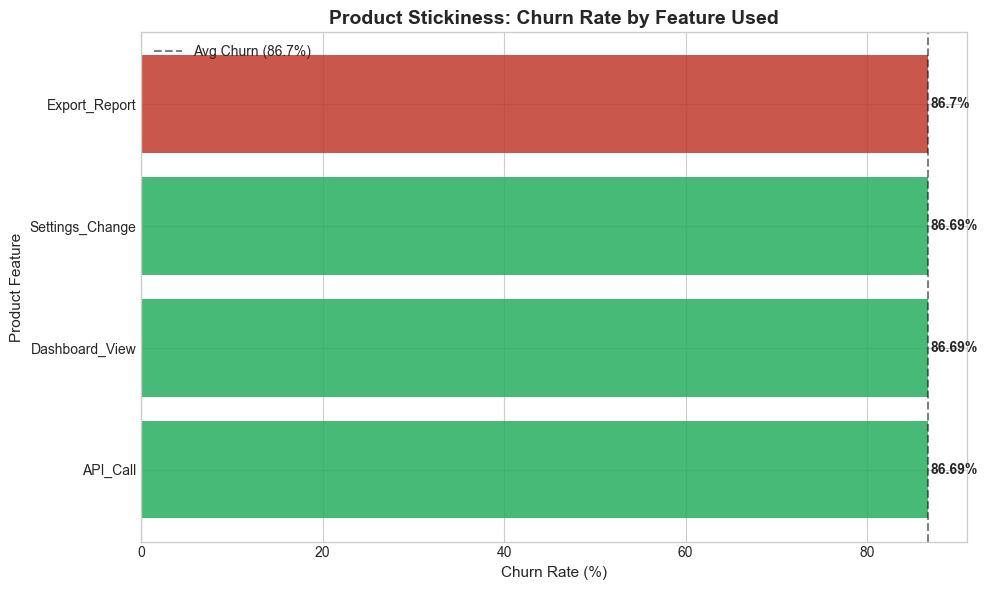

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your local CSV
df = pd.read_csv("data/csv_files/feature_stickness.csv")

# 2. Sort by churn rate for a better visual story
df = df.sort_values(by='churn_rate', ascending=True)

# 3. Create the Plot
plt.figure(figsize=(10, 6))

# Highlight "Sticky" vs "Risk" features (Green for Low Churn, Red for High)
avg_churn = df['churn_rate'].mean()
colors = ['#27ae60' if x < avg_churn else '#c0392b' for x in df['churn_rate']]

plt.barh(df['feature_used'], df['churn_rate'], color=colors, alpha=0.85)

# 4. Add the "Business Insight" line
plt.axvline(avg_churn, color='black', linestyle='--', alpha=0.5, label=f'Avg Churn ({avg_churn:.1f}%)')

# 5. Professional Labeling
plt.title("Product Stickiness: Churn Rate by Feature Used", fontsize=14, fontweight='bold')
plt.xlabel("Churn Rate (%)", fontsize=11)
plt.ylabel("Product Feature", fontsize=11)
plt.legend()

# 6. Add data labels on the bars
for i, v in enumerate(df['churn_rate']):
    plt.text(v + 0.3, i, f"{v}%", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("visuals/feature_stickiness_chart.png", dpi=300)
plt.show()

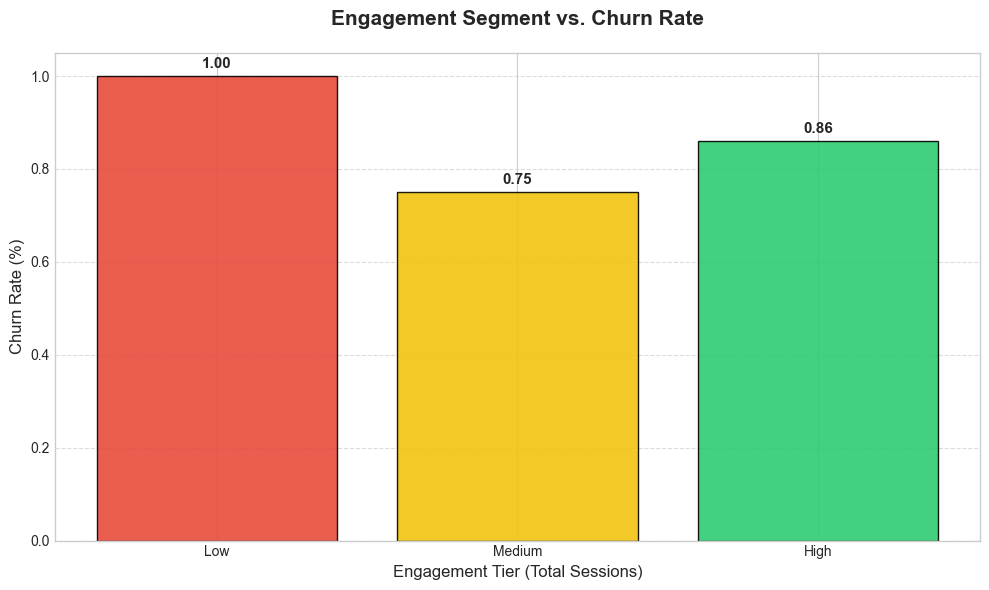

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your local CSV
df = pd.read_csv("data/csv_files/churn_by_engagement.csv")

# 2. Map segments to numbers for correct sorting (Low -> Medium -> High)
segment_order = {'Low': 1, 'Medium': 2, 'High': 3}
df['sort_order'] = df['engagement'].map(segment_order)
df = df.sort_values('sort_order')

# 3. Create the Plot
plt.figure(figsize=(10, 6))

# Gradient color: Red (High Risk) to Green (Low Risk)
colors = ['#e74c3c', '#f1c40f', '#2ecc71'] 

bars = plt.bar(df['engagement'], df['churn_rate'], color=colors, alpha=0.9, edgecolor='black')

# 4. Styling
plt.title("Engagement Segment vs. Churn Rate", fontsize=15, fontweight='bold', pad=20)
plt.ylabel("Churn Rate (%)", fontsize=12)
plt.xlabel("Engagement Tier (Total Sessions)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Add Data Labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# 6. Final Export
plt.tight_layout()
plt.savefig("visuals/churn_by_engagement_chart.png", dpi=300)
plt.show()

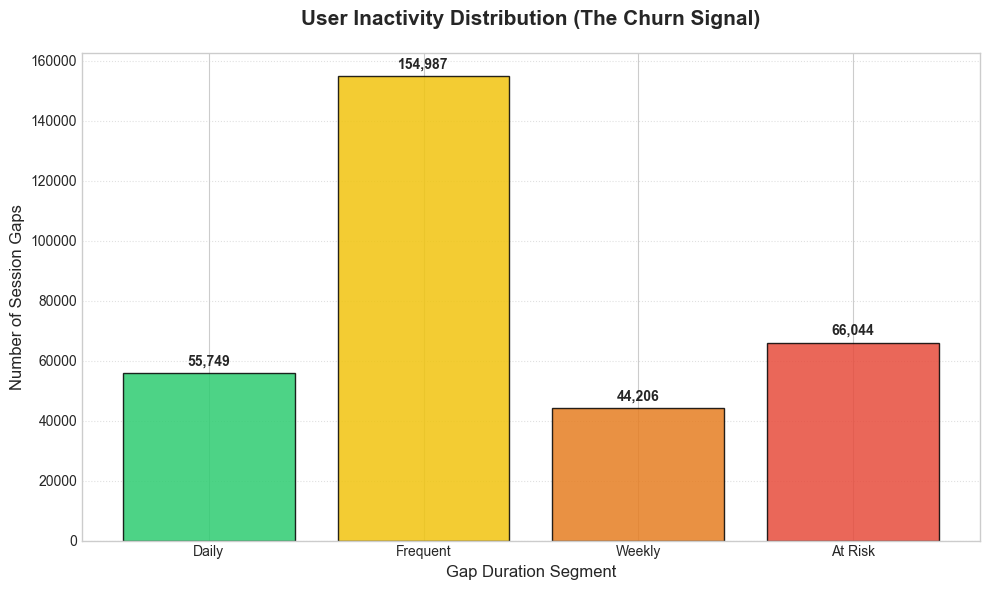

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your local CSV
# This should be the output of your Session Gap SQL
df = pd.read_csv("data/csv_files/session_gap_analysis.csv")

# 2. Aggregate the counts for the segments
# If your CSV is the raw per-session gap, we need to count them
gap_counts = df['gap_segment'].value_counts().reindex(['Daily', 'Frequent', 'Weekly', 'At Risk'])

# 3. Create the Plot
plt.figure(figsize=(10, 6))

# Color scheme: Green (Healthy) to Red (Danger)
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

bars = plt.bar(gap_counts.index, gap_counts.values, color=colors, alpha=0.85, edgecolor='black')

# 4. Professional Styling
plt.title("User Inactivity Distribution (The Churn Signal)", fontsize=15, fontweight='bold', pad=20)
plt.ylabel("Number of Session Gaps", fontsize=12)
plt.xlabel("Gap Duration Segment", fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.6)

# 5. Add Data Labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + (max(gap_counts.values)*0.01),
             f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

# 6. Final Export
plt.tight_layout()
plt.savefig("visuals/session_gap_analysis.png", dpi=300)
plt.show()

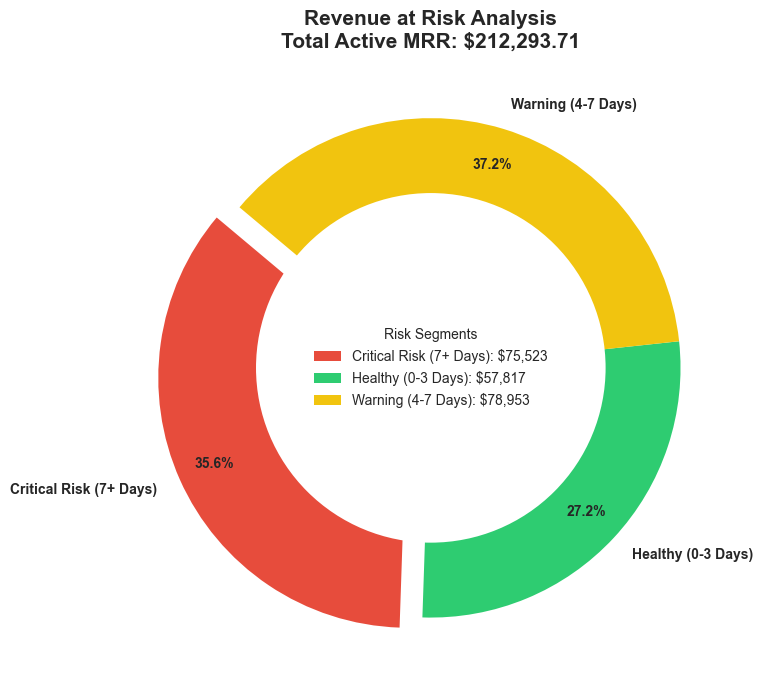

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your local CSV
df = pd.read_csv("data/csv_files/revenue_at_risk.csv")

# 2. Setup colors and explode effect for the "Critical" slice
colors = ['#e74c3c', '#2ecc71', '#f1c40f'] # Red, Green, Yellow
explode = (0.1, 0, 0) # Pop out the Critical Risk slice

# 3. Create Donut Chart
plt.figure(figsize=(10, 7))
plt.pie(df['total_mrr_at_risk'], labels=df['risk_profile'], autopct='%1.1f%%', 
        startangle=140, colors=colors, explode=explode, pctdistance=0.85,
        textprops={'fontweight': 'bold'})

# Draw circle to make it a donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# 4. Adding Data Labels (Dollar Amounts)
total_risk = df['total_mrr_at_risk'].sum()
plt.title(f"Revenue at Risk Analysis\nTotal Active MRR: ${total_risk:,.2f}", fontsize=15, fontweight='bold')

# 5. Legend with dollar amounts
legend_labels = [f"{row['risk_profile']}: ${row['total_mrr_at_risk']:,.0f}" for _, row in df.iterrows()]
plt.legend(legend_labels, loc="center", title="Risk Segments", frameon=False)

plt.tight_layout()
plt.savefig("visuals/revenue_at_risk_donut.png", dpi=300)
plt.show()